214211 Kymograph 2.h5


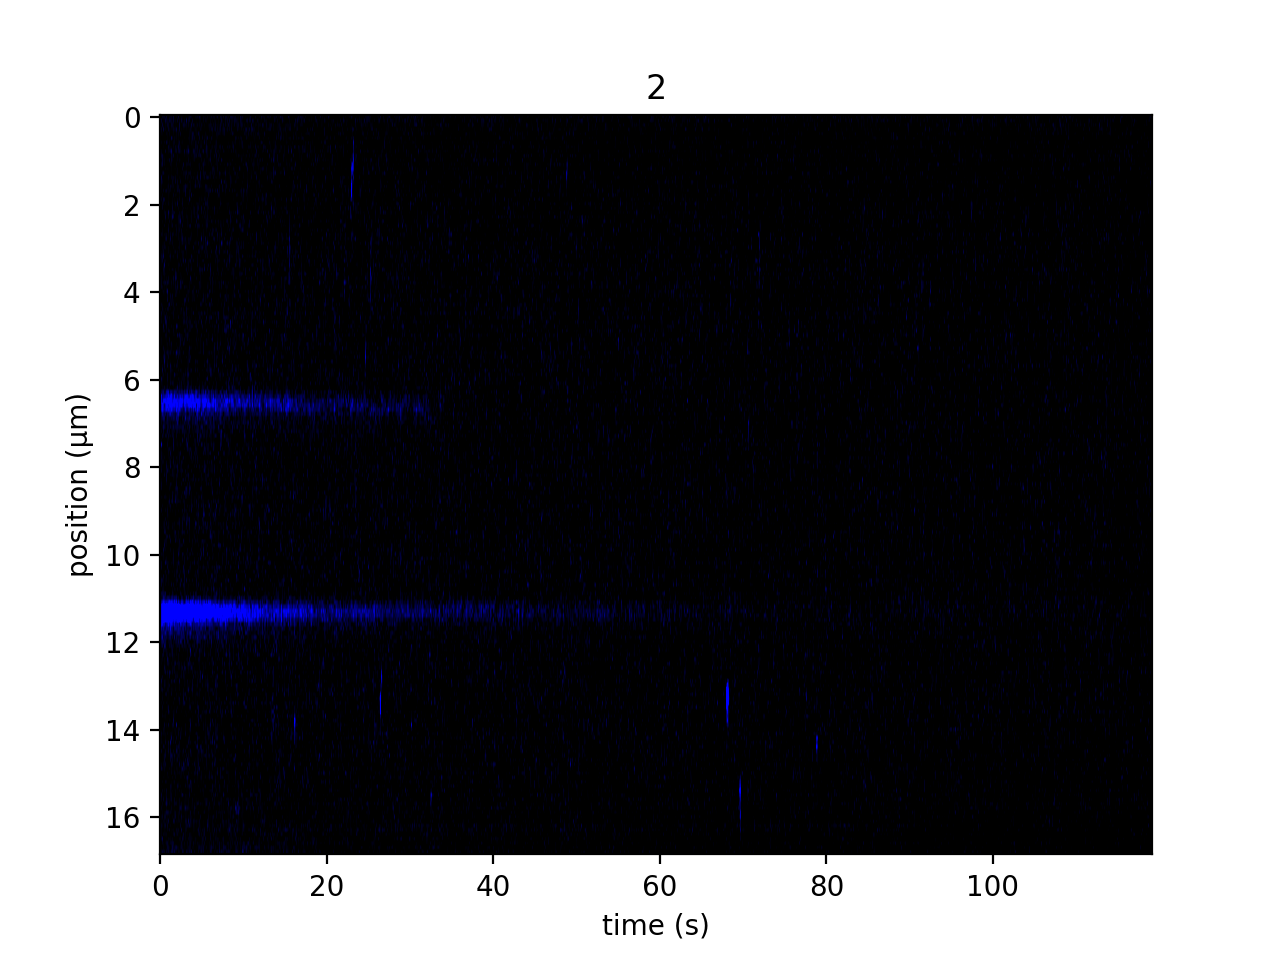

In [28]:
# %created by Sushil Pangeni
# %Ha Lab
# %3/26/2022
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import lumicks.pylake as lk

%matplotlib widget
directory_h = r"G:\Rad51_eGFP\03092024\100um"
d_current = r"/"
directory_save = directory_h + d_current
filename = glob.glob(directory_save+'*Kymograph 2.h5')
#print(filename)
##############################Naming the file to record veocity##################################
#1 uncomment codes below to aavoidautomatically create the file and save diffusion numbers
a = filename[0]
b = a[38:69]
print(b)
#################################################################################################
file = lk.File(filename[0])
name, kymo = file.kymos.popitem()
#%matplotlib widget
plt.figure(dpi=200)
#kymo.plot(channel='red', aspect="auto",vmin=45,vmax=67)
kymo.plot(channel='blue', aspect="auto",vmin=2,vmax=12)#adjustment=lk.ColorAdjustment([3, 5, 1], [5, 25, 12], mode='absolute'))
#####Opening the file for recording velocity in the same place where your kymograph is located######
#comment out code below if you comment the file section above
# file_name = b+".txt"
# completeName = os.path.join(directory_h, file_name)
# file1 = open(completeName, "w")
#file1.write(f'{b}\n')
#plt.savefig(directory_save+'hbd.svg') #only if you want to save figure.
#adjustment=lk.ColorAdjustment(0, 98, mode="percentile")
#plt.savefig(directory_save+'Nucleationreferencekymo_blue'+'.svg',format='svg', bbox_inches='tight')

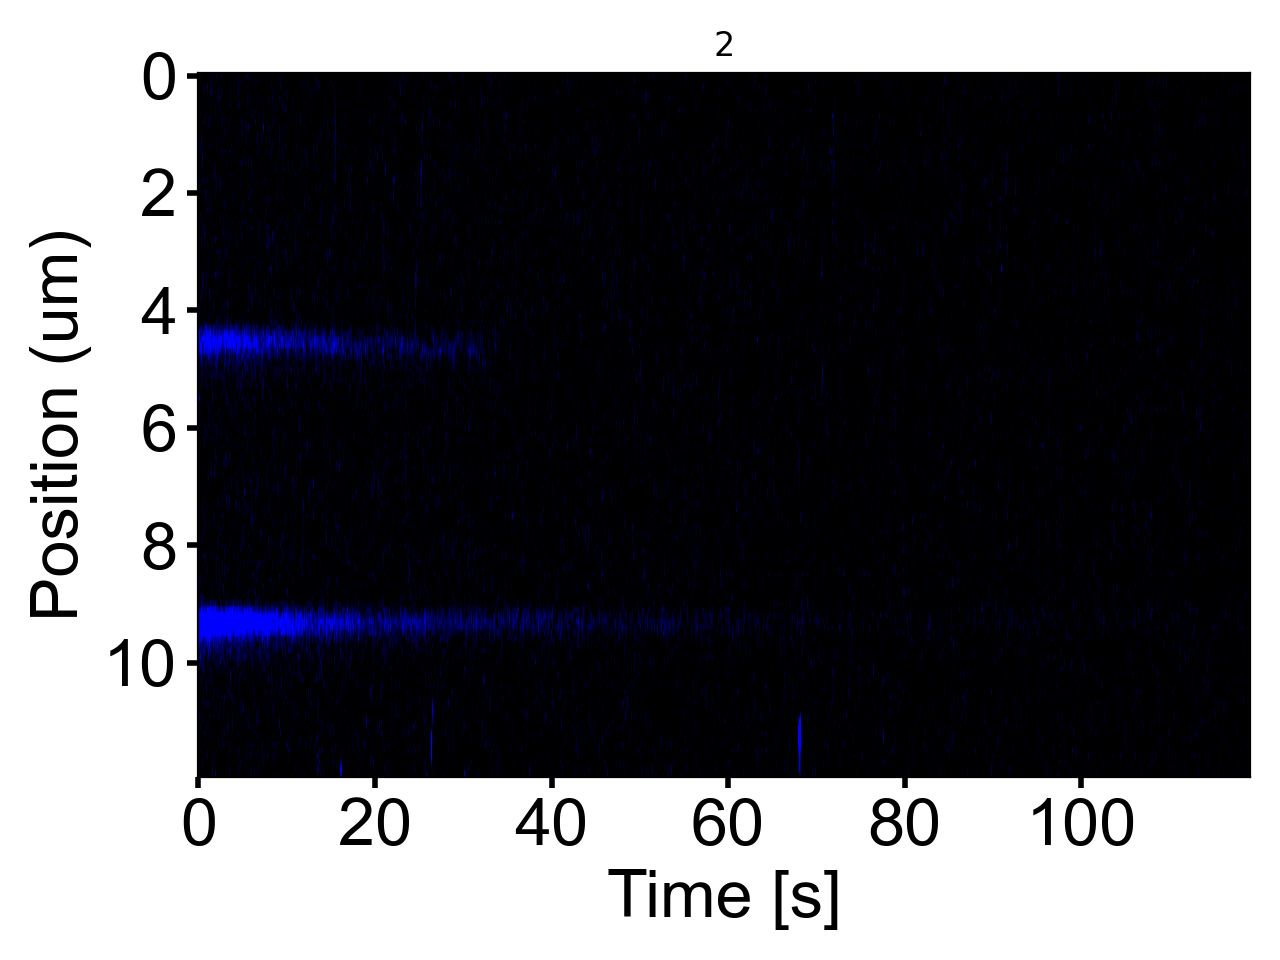

In [29]:
data =kymo["0s":"3000s"].crop_by_distance(2,14)#.calibrate_to_kbp(48502) #this will crop by time(x-axis), 
#distance(y-axis) and then convert y-axis to kbp.It is essential that you look numbers carefully in previous kymos otherwise your 
#velocity will be off
%matplotlib widget
plt.figure(dpi=200)
data.plot(channel='blue', aspect='auto',vmin=2,vmax=12)
#plt.title("")
#plt.ylabel('Position bp')
plt.xlabel('Time [s]',fontsize=24,fontname="Arial")
plt.ylabel('Position (um)',fontsize=24,fontname="Arial")
plt.tick_params(axis="x", direction="out", length=4, width=2)
plt.tick_params(axis="y", direction="out", length=4, width=2)
plt.xticks(fontsize=20, fontname="Arial")
plt.yticks(fontsize=20,fontname="Arial")
x_tick_labels = plt.gca().get_xticklabels()
y_tick_labels = plt.gca().get_yticklabels()
font_properties = {'family': 'arial', 'size':24}
for label in x_tick_labels:
    label.set_fontproperties(font_properties)
for label in y_tick_labels:
    label.set_fontproperties(font_properties)
plt.tight_layout()
plt.show()
#plt.savefig(directory_save+'molecule 4'+'.svg')
#plt.savefig(directory_save+'1mM molecule 5'+'.svg',format='svg', bbox_inches='tight')
#data.plot_with_force("2x", "red", adjustment=lk.ColorAdjustment(0, 15))

In [16]:
blue=data._get_photon_count('blue')
data._get_photon_count()

In [139]:
%matplotlib widget
kymowidget = lk.KymoWidgetGreedy(data, 'red',vmin=0,vmax=3,aspect='auto',min_length=3, pixel_threshold=3,track_width=2, window=6, sigma=1.5)
plt.ylabel('Position [um]')
plt.xlabel('Time [s]')

Text(0.5, 29.000000000000014, 'Time [s]')

Next,lets export the traced lines and see if the number of traces we tracked above matches.

KymoTrackGroup(N=1)
KymoTrack(N=866)


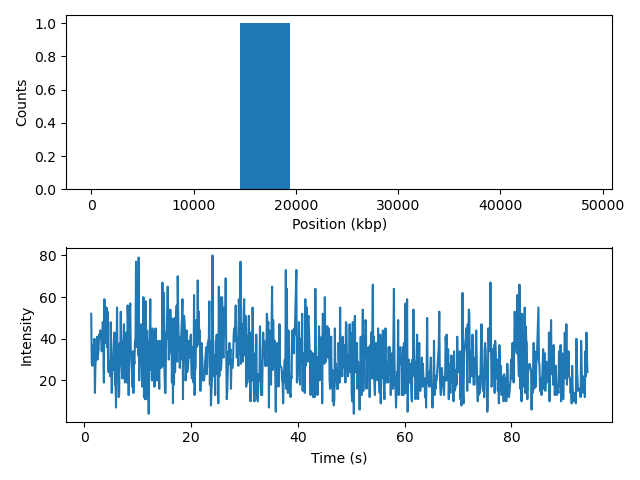

In [140]:
tracks = kymowidget.tracks #this gives you the kymolines,it should match the lines you see above.
#If not, go back above and remove tiny traces
print(tracks)
c=directory_save+b+'.csv'
tracks.save(c)
#next, we will extract the time and p
# ixel size  for further calculations
#len(lines)
longest_track_idx = np.argmax([len(track) for track in tracks])
longest_track = tracks[longest_track_idx]
print(longest_track)

plt.figure(dpi=100)
plt.subplot(2,1,1)
tracks.plot_binding_histogram(kind="binding")
plt.title('')
plt.tight_layout()
plt.subplot(2,1,2)
plt.plot(longest_track.seconds, longest_track.photon_counts)
plt.xlabel('Time (s)')
plt.ylabel('Intensity')
plt.tight_layout()
plt.show()
#plt.savefig(directory_save+'1mM molecule 5'+'intensity'+'.svg',format='svg', bbox_inches='tight')


Next, lets look at the individual tarces or all the traces at once.

longest_track_idx = np.argmax([len(track) for track in tracks])
longest_track = tracks[longest_track_idx]

plt.figure()
plt.plot(longest_track.seconds, longest_track.sample_from_image(num_pixels=3))
plt.xlabel('Time (s)')
plt.ylabel('Intensity')
plt.show()

In [35]:
# import pandas as pd

# # Assuming longest_track.seconds and longest_track.photon_counts are NumPy arrays or lists
# data = {'Time (s)': longest_track.seconds, 'Intensity': longest_track.sample_from_image(num_pixels=0)}
# df = pd.DataFrame(data)

# # Specify the path where you want to save the Excel file
# c='molecule 5'
# excel_file_path = directory_save+b+c+'.xlsx'

# # Export the data to Excel
# df.to_excel(excel_file_path, index=False)

# print(f'The data has been exported to {excel_file_path}')


In [36]:
# %matplotlib widget

# xs=tracks.dwell_times()
# multi_dwell=tracks.fit_binding_times(n_components=1)
# print(multi_dwell.lifetimes)  # list of bound lifetimes
# print(multi_dwell.amplitudes)  # list of fractional amplitudes for each component

In [141]:
import pandas as pd
filename_1 = glob.glob(c)
df=pd.read_csv(filename_1[0], delimiter=';')
print(df)
for _ in range(2):
    df=pd.read_csv(filename_1[0], delimiter=';')
    # df.rpow
    # df.columns
    # Read the data

    with open(filename_1[0],"r") as f:
        data = f.read().split("\n")

    # Remove the 1st line
    del data[0]
    # Save the data
    with open(filename_1[0], "w") as f:
        f.write("\n".join(data))
    print(df)

df[df["# track index"] == 2]["# track index"]
df2 = df
for i in df["# track index"].unique():
    # print(i)

    #df2[f"track index {i}"] = df[df["# track index"] == i]["# track index"]
    df2[f"time {i}"] = df[df["# track index"] == i]["time (seconds)"]
    df2[f"position {i}"] = df[df["# track index"] == i]["position (kbp)"]
print(df2)
df2.to_csv(c) #name of the Kymo
import pandas as pd
df3=pd.read_csv(filename_1[0])
df3= df3.apply(lambda x: pd.Series(x.dropna().values)).fillna(' ')
print(df3)
df3.to_csv(c) #name of the Kymo


                                                                                                                  # Exported with pylake v1.3.1 | track coordinates v4
# track index time (pixels)            coordinate (pixels)      time (seconds)           position (kbp)                        minimum observable duration (seconds)  
0             1.300000000000000000e+01 5.122222222222222143e+01 1.284275199999999950e+00 1.713365670498084364e+04                                       3.951616e-01  
              1.400000000000000000e+01 5.246666666666596512e+01 1.383065600000000117e+00 1.754991908045953460e+04                                       3.951616e-01  
              1.500000000000000000e+01 5.148148148148148096e+01 1.481856000000000062e+00 1.722037803320561943e+04                                       3.951616e-01  
              1.600000000000000000e+01 5.185714285714285410e+01 1.580646400000000007e+00 1.734603546798029492e+04                                       3.951616e-01 

[1.71261195e+00 1.71860925e+04]


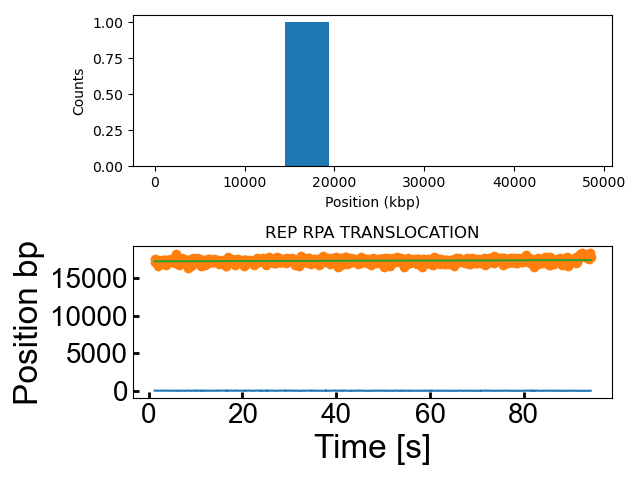

[1.7126119516564344]


In [142]:
start=0
stop=30000
translocation_speed_1=[]
from scipy.optimize import curve_fit
def f(x, A, B): # this is your 'straight line' y=f(x)
    return A*x + B
lines=tracks
for i in range(len(lines)):
    example_line= lines[i]
    time=example_line.seconds
    positions=example_line.position
    popt, pcov=curve_fit(f, example_line.seconds[start:stop], example_line.position[start:stop]) # your data x, y to fit
    translocation_speed_1.append(popt[0])
    print(popt)
    #print(popt1)
    
    plt.plot(example_line.seconds[:], example_line.position[:], 'o', label='data')
    plt.plot(example_line.seconds[start:stop], f(example_line.seconds[start:stop], *popt), '-', label='Fit')
    #plt.plot(example_line.seconds[63:], f(example_line.seconds[63:], *popt1), '-', label='Fit_1')
    plt.title("REP RPA TRANSLOCATION")#give your  title as you want
    plt.xlabel('Time [s]',fontsize=24,fontname="Arial")
    plt.ylabel('Position bp',fontsize=24,fontname="Arial")
    plt.tick_params(axis="x", direction="in", length=4, width=2)
    plt.tick_params(axis="y", direction="in", length=4, width=2)
    plt.xticks(fontsize=20, fontname="Arial")
    plt.yticks(fontsize=20,fontname="Arial")
    plt.tight_layout()
    plt.show()
    #i=i+1
print(translocation_speed_1)        

In [143]:
for i in translocation_speed_1:
    file1 = open(completeName, "a")
    file1.write(f'{np.absolute(i)}\n')
    file1.close()

[-9.12134449e-01  3.11501421e+04]


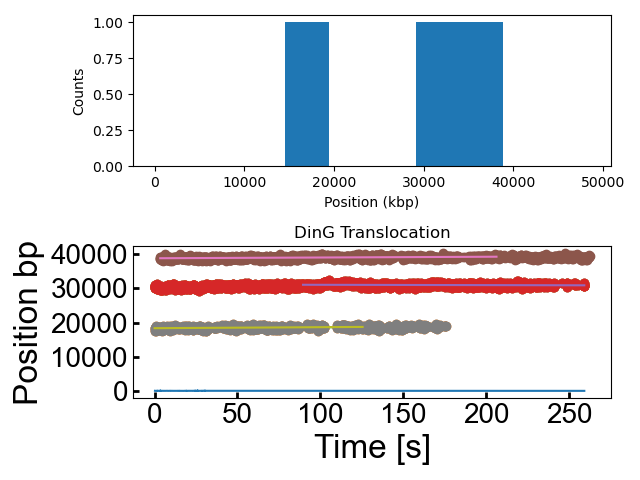

In [50]:
#############################################################################################
example_line= tracks[1]  # this is very critical.If you want to visualise individual kymolines then change the lie as per this this, 
#normally in python the numbering starts fron 0.So if number of kymoline is 2 then,you can input 1 and 2 seperately.Note your lines 
# should look similar. 
# print(len(example_line.seconds))
# print(len(example_line.position))
# print(len(example_line.position)/(example_line.seconds[-1]))
# %matplotlib widget
# plt.plot(example_line.seconds, example_line.position,'ro',linewidth=3)
# plt.title("REP RPA TRANSLOCATION")#give your  title as you want
# plt.xlabel('Time [s]',fontsize=24,fontname="Arial")
# plt.ylabel('Position bp',fontsize=24,fontname="Arial")
# plt.tick_params(axis="x", direction="in", length=4, width=2)
# plt.tick_params(axis="y", direction="in", length=4, width=2)
# plt.xticks(fontsize=20, fontname="Arial")
# plt.yticks(fontsize=20,fontname="Arial")
# plt.tight_layout()
# plt.show()
##########################################################################################################Run thi s shell differently , one at a time
start=2000
stop=6550

from scipy.optimize import curve_fit

def f(x, A, B): # this is your 'straight line' y=f(x)
    return A*x + B

popt, pcov=curve_fit(f, example_line.seconds[start:stop], example_line.position[start:stop]) # your data x, y to fit
#popt1, pcov1=curve_fit(f, example_line.seconds[63:], example_line.position[63:])
print(popt)
#print(popt1)

plt.plot(example_line.seconds[:], example_line.position[:], 'o', label='data')
plt.plot(example_line.seconds[start:stop], f(example_line.seconds[start:stop], *popt), '-', label='Fit')
#plt.plot(example_line.seconds[63:], f(example_line.seconds[63:], *popt1), '-', label='Fit_1')
plt.title("DinG Translocation")#give your  title as you want
plt.xlabel('Time [s]',fontsize=24,fontname="Arial")
plt.ylabel('Position bp',fontsize=24,fontname="Arial")
plt.tick_params(axis="x", direction="in", length=4, width=2)
plt.tick_params(axis="y", direction="in", length=4, width=2)
plt.xticks(fontsize=20, fontname="Arial")
plt.yticks(fontsize=20,fontname="Arial")
plt.tight_layout()
plt.show()
############################################################Can run this shell differently
# from openpyxl import load_workbook
# import pandas as pd
# time_excel=example_line.seconds
# position_excel=example_line.position
# writer = pd.ExcelWriter('F:/DNAb/09172022/excels/kymo55_trace5.xlsx', engine='openpyxl') 
# wb  = writer.book
# df = pd.DataFrame({'Time1': time_excel,
#                   'Positions':position_excel,})
# df.to_excel(writer, index=False)
# wb.save('F:/DNAb/09172022/excels/kymo55_trace5.xlsx')

In [57]:

file1 = open(completeName, "a")
file1.write(f'{np.absolute(popt[0])}\n')
file1.close()


In [31]:
from openpyxl import load_workbook
import pandas as pd
time_excel=example_line.seconds[start:stop]
position_excel=example_line.position[start:stop]
writer = pd.ExcelWriter('F:/Sushil/Rep/982022/kymo1.xlsx', engine='openpyxl') 
wb  = writer.book
df = pd.DataFrame({'Time1': time_excel,
                  'Positions':position_excel,})
df.to_excel(writer, index=False)
wb.save('F:/Sushil/Rep/982022/kymo1.xlsx')

In [29]:
a='i like'
b='you'
c='.csv'
s=a+b+c
print(s)

i likeyou.csv


In [111]:
a=1129+1427+926
a/3

1160.6666666666667

In [13]:
import random

print(random.randint(1,5))

2


In [10]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
start=0
stop=3000
translocation_speed=[]
from scipy.optimize import curve_fit
def f(x, A, B): # this is your 'straight line' y=f(x)
    return A*x + B
lines=tracks
for i in range(len(lines)):
    example_line= lines[i]
    time=example_line.seconds
    positions=example_line.position
    r = 0
    while abs(r) <0.95:
        slope, intercept, r, p, stderr = linregress(time, positions)
        print(r)
        positions= [i + np.random.normal(0, 0.1) for i in positions]
        translocation_speed.append(slope)
    #print(popt1)
        %matplotlib inline
        plt.scatter(time, positions)
        plt.plot(time, [slope*i + intercept for i in time], '-r')
        plt.title("REP RPA TRANSLOCATION")#give your  title as you want
        plt.xlabel('Time [s]',fontsize=24,fontname="Arial")
        plt.ylabel('Position bp',fontsize=24,fontname="Arial")
        plt.tick_params(axis="x", direction="in", length=4, width=2)
        plt.tick_params(axis="y", direction="in", length=4, width=2)
        plt.xticks(fontsize=20, fontname="Arial")
        plt.yticks(fontsize=20,fontname="Arial")
        plt.tight_layout()
        plt.show()

print(translocation_speed) 

NameError: name 'tracks' is not defined